# Evaluation of trajectory inference stability through repeated simulations
***

Jan T. Schleicher, 2025

Here, we evaluate the hierarchical clustering solutions of exploratory trajectory inference for repeated Markov chain simulations.
We use these repeated analyses to assess
1. the best number of lineages, determined through silhouette scores
2. the uncertainty of the inferred lineages through comparison of the results of repeated runs

In [ ]:
import glob
import json
import logging
import sys

import cy2path as c2p
import matplotlib as mpl
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from dtaidistance import dtw_ndim
from matplotlib import pyplot as plt

In [2]:
mpl.rcParams["figure.dpi"] = 300
logging.disable(sys.maxsize)

In [3]:
# Import AnnData object
adata = sc.read_h5ad("../data/tex_data_chronic_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [ ]:
# Load clustering results
SIMULATIONS_PATH = "../output/markov_chains/20250512_1405"
LINEAGE_PATH = "../output/lineage_clustering/20250512_1738"
silhouette_scores_dict = {}
clusterings_dict = {}
markov_chains_dict = {}
markov_chains_params_dict = {}
for file in glob.glob(f"{LINEAGE_PATH}/silhouette_scores_*.json"):
    run_number = int(file.split("_")[-1].split(".")[0])
    markov_chains_params_dict[run_number] = json.load(
        open(f"{SIMULATIONS_PATH}/params_{run_number}.json")
    )
    markov_chains_dict[run_number] = np.load(
        f"{SIMULATIONS_PATH}/simulations_{run_number}.npy"
    )[:, : markov_chains_params_dict[run_number]["convergence"]]
    silhouette_scores_dict[run_number] = json.load(open(file))
    clusterings_dict[run_number] = {}
    for clust_file in glob.glob(f"{LINEAGE_PATH}/*_{run_number}.npy"):
        num_lineages = int(clust_file.split("_")[-2])
        clusterings_dict[run_number][num_lineages] = np.load(clust_file)

In [5]:
silhouette_scores_df = pd.DataFrame(silhouette_scores_dict)
silhouette_scores_df.index.name = "num_lineages"
silhouette_scores_df = silhouette_scores_df.reset_index().melt(
    id_vars="num_lineages", var_name="run", value_name="silhouette_score"
)

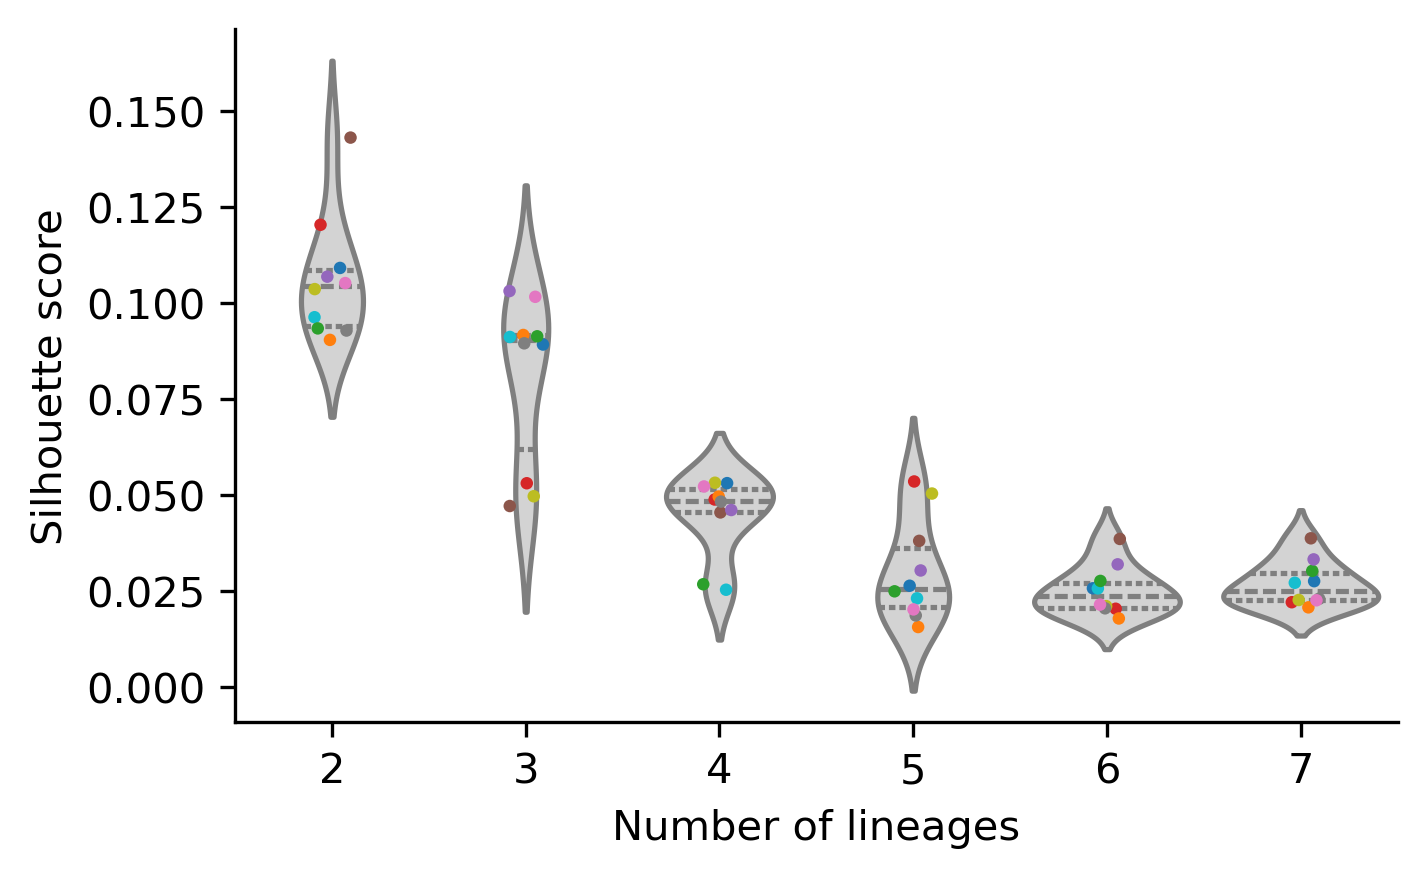

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.violinplot(
    silhouette_scores_df,
    x="num_lineages",
    y="silhouette_score",
    inner="quartiles",
    color="lightgrey",
    ax=ax,
)
sns.stripplot(
    silhouette_scores_df,
    x="num_lineages",
    y="silhouette_score",
    hue="run",
    dodge=False,
    palette="tab10",
    legend=False,
    ax=ax,
    s=3,
)
ax.set_xlabel("Number of lineages")
ax.set_ylabel("Silhouette score")
sns.despine(fig)

In [7]:
adata_ = adata.copy()

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

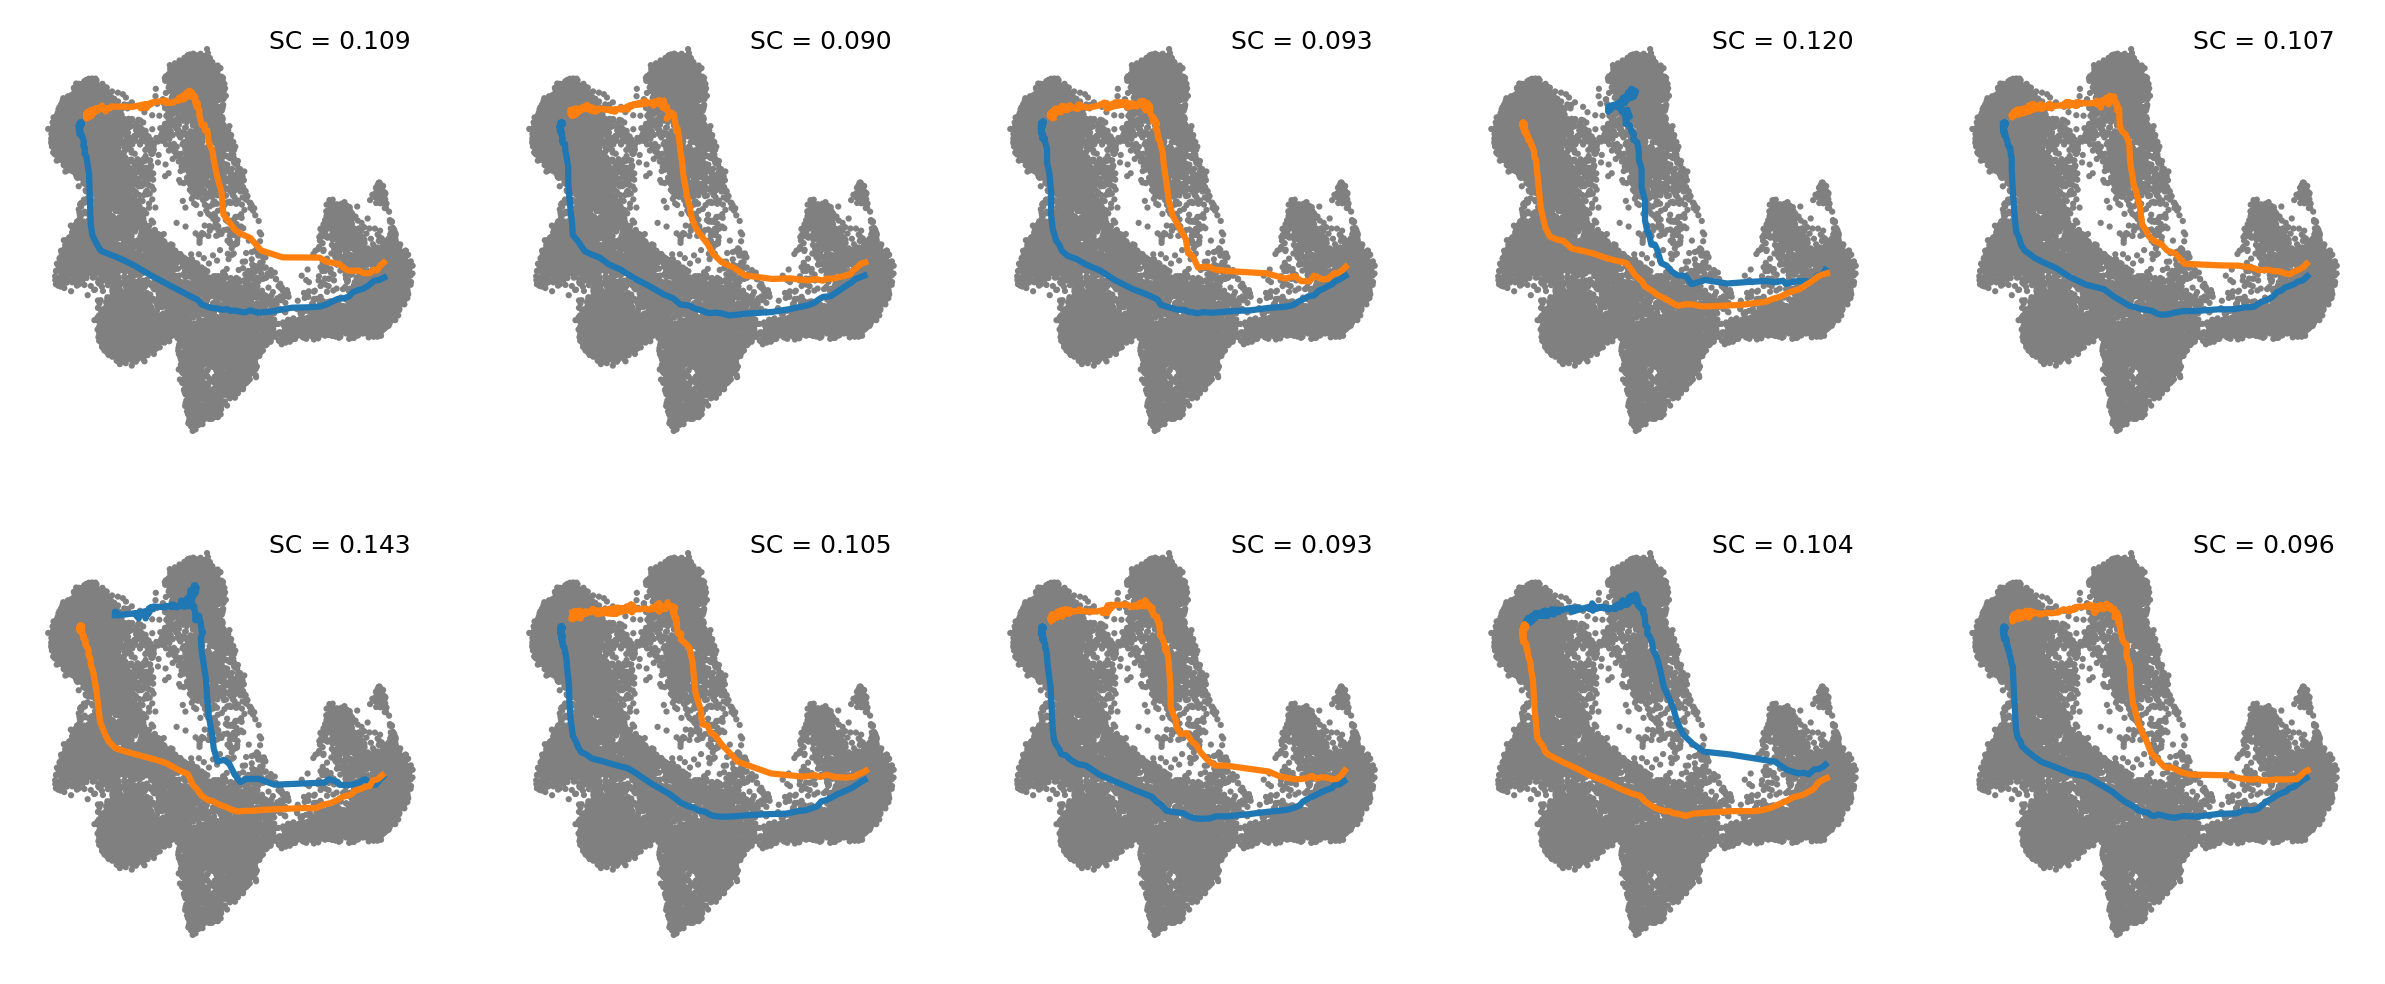

In [ ]:
# Plot for 2 lineages
n_lineages = 2
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for run_number, markov_chains in markov_chains_dict.items():
    adata_.uns["markov_chain_sampling"] = {}
    adata_.uns["markov_chain_sampling"]["state_indices"] = markov_chains
    adata_.uns["cytopath"] = {}
    adata_.uns["cytopath"]["lineage_inference_clusters"] = clusterings_dict[run_number][
        n_lineages
    ]
    c2p.plot_cytopath_lineages(adata_, basis="umap", ax=axs.flat[run_number])
    axs.flat[run_number].text(
        0.95,
        1.0,
        f"SC = {silhouette_scores_dict[run_number][str(n_lineages)]:.3f}",
        ha="right",
        va="top",
        transform=axs.flat[run_number].transAxes,
        size=6,
    )

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

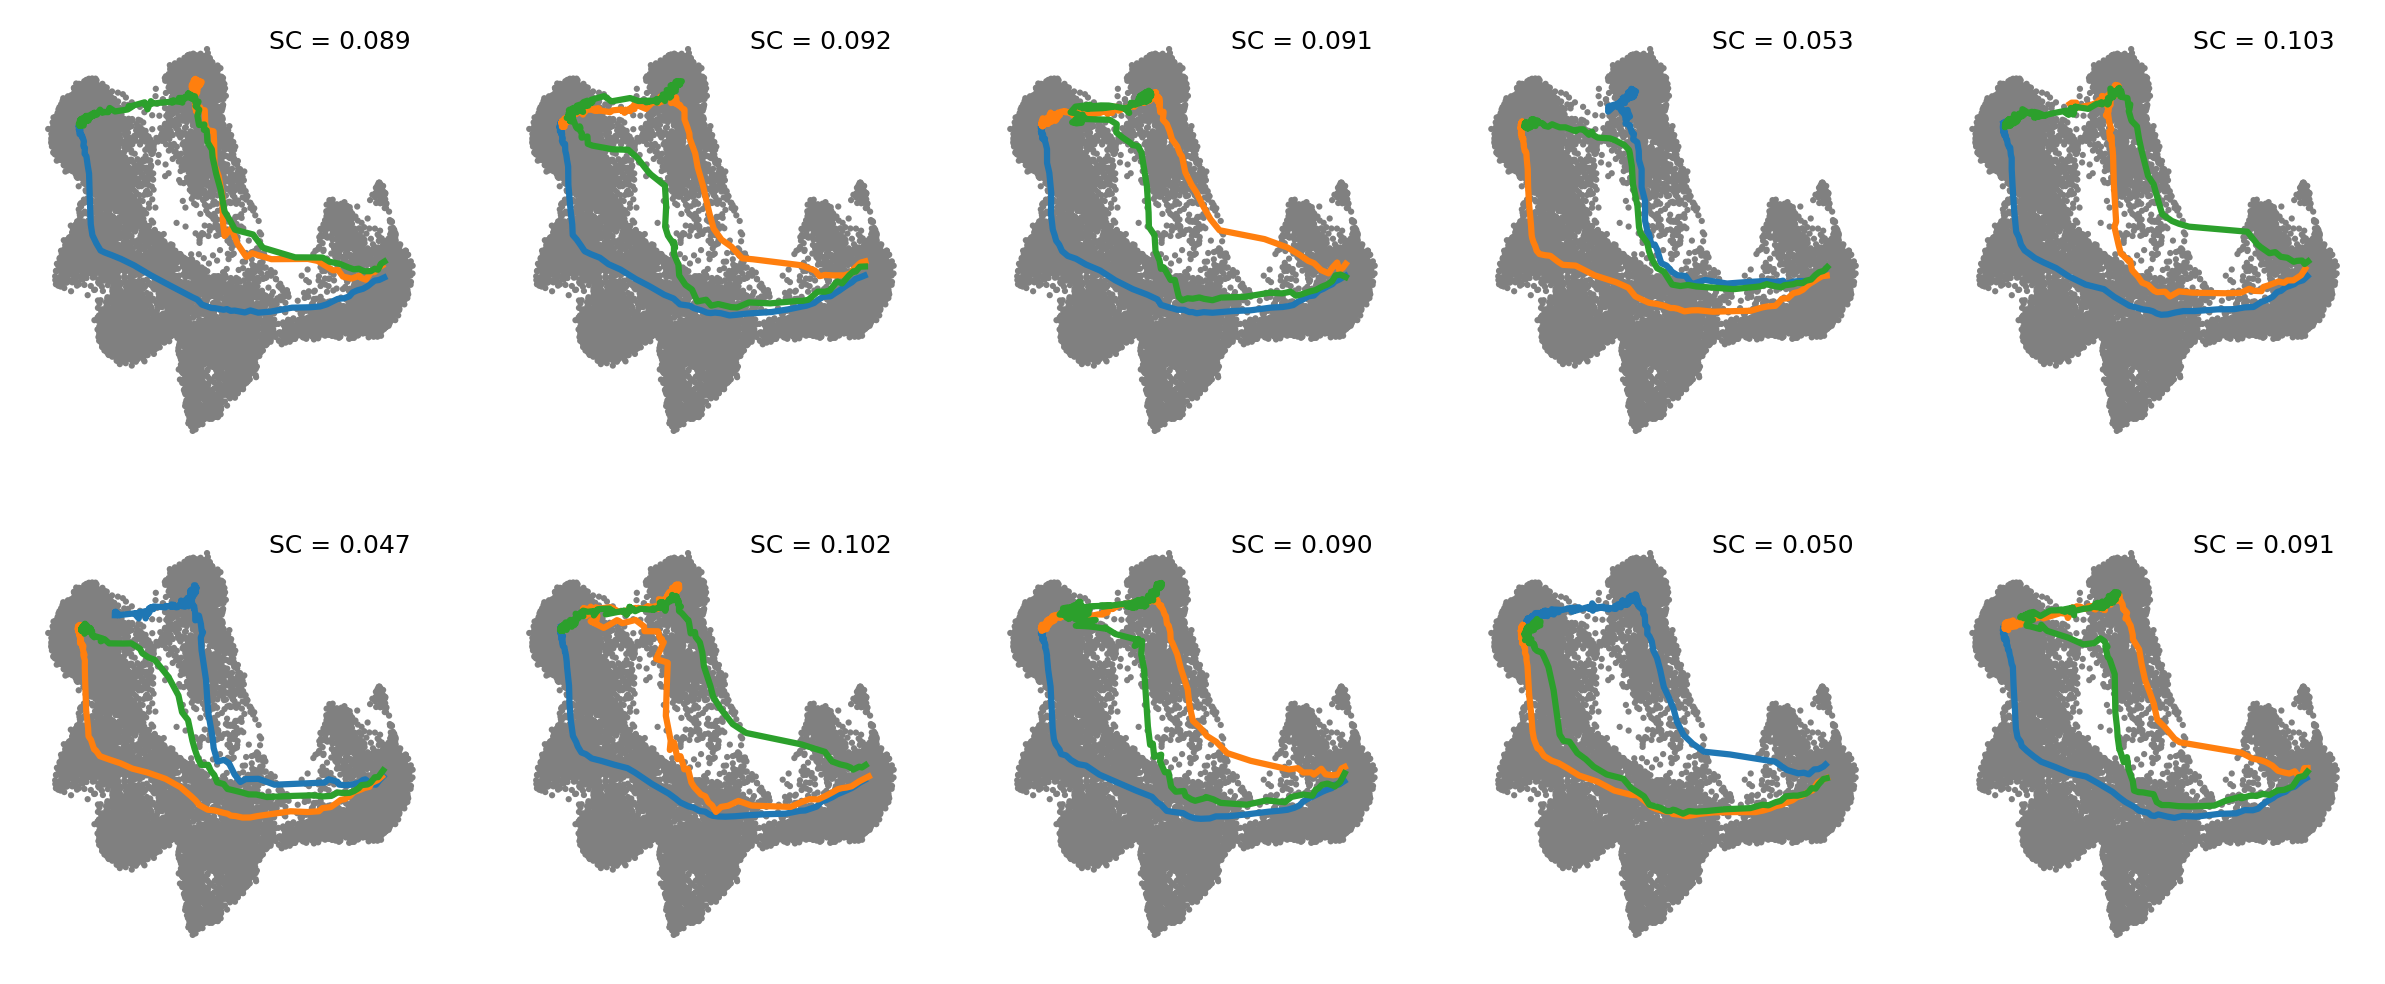

In [ ]:
# Plot for 3 lineages
n_lineages = 3
fig, axs = plt.subplots(2, 5, figsize=(10, 4))

for run_number, markov_chains in markov_chains_dict.items():
    adata_.uns["markov_chain_sampling"] = {}
    adata_.uns["markov_chain_sampling"]["state_indices"] = markov_chains
    adata_.uns["cytopath"] = {}
    adata_.uns["cytopath"]["lineage_inference_clusters"] = clusterings_dict[run_number][
        n_lineages
    ]
    c2p.plot_cytopath_lineages(adata_, basis="umap", ax=axs.flat[run_number])
    axs.flat[run_number].text(
        0.95,
        1.0,
        f"SC = {silhouette_scores_dict[run_number][str(n_lineages)]:.3f}",
        ha="right",
        va="top",
        transform=axs.flat[run_number].transAxes,
        size=6,
    )

In [10]:
# Compute the trajectory coordinates in PC and UMAP space
trajectories_pca = {}
trajectories_umap = {}
n_steps = markov_chains_params_dict[0]["convergence"]
for run_number, markov_chains in markov_chains_dict.items():
    trajectories_pca[run_number] = {}
    trajectories_umap[run_number] = {}
    for n_lineages, clustering in clusterings_dict[run_number].items():
        trajectories_pca[run_number][n_lineages] = np.zeros(
            (n_lineages, n_steps, adata.obsm["X_pca"].shape[1]), dtype="double"
        )
        trajectories_umap[run_number][n_lineages] = np.zeros(
            (n_lineages, n_steps, adata.obsm["X_umap"].shape[1])
        )
        for i in range(n_lineages):
            indices = np.where(clustering == i + 1)[0]
            chains = markov_chains[indices]
            trajectories_pca[run_number][n_lineages][i, :, :] = np.median(
                adata.obsm["X_pca"][chains], axis=0
            )
            trajectories_umap[run_number][n_lineages][i, :, :] = np.median(
                adata.obsm["X_umap"][chains], axis=0
            )

In [ ]:
# Compute lineage mapping between runs, using lineages from first run as reference
# Output for each run and n_lineages is the order of lineages matching the reference lineages
lineage_orders = {n_lineages: [list(range(n_lineages))] for n_lineages in range(2, 8)}
ref_trajectories = trajectories_pca[0]
for run_number in range(1, len(trajectories_pca)):
    trajectories = trajectories_pca[run_number]
    for n_lineages, trajectory_coords in trajectories.items():
        dist_mat = dtw_ndim.distance_matrix_fast(
            np.vstack([ref_trajectories[n_lineages], trajectory_coords]),
            block=((0, n_lineages), (n_lineages, 2 * n_lineages)),
        )[:n_lineages, n_lineages:]
        mapping = {}
        # Greedily choose the argmin as the mapping
        for i in range(n_lineages):
            idx_ref, idx_other = np.unravel_index(dist_mat.argmin(), dist_mat.shape)
            mapping[idx_ref] = idx_other
            # Remove rows and cols that are already mapped
            dist_mat[idx_ref, :] = np.inf
            dist_mat[:, idx_other] = np.inf
        lineage_orders[n_lineages].append([mapping[i] for i in range(n_lineages)])

In [ ]:
# Compute mean and std of inferred UMAP coordinates
lineage_coords_all = {}
for n_lineages in range(2, 8):
    lineage_coords_all[n_lineages] = np.stack(
        [
            trajectories_umap[run_number][n_lineages][
                lineage_orders[n_lineages][run_number]
            ]
            for run_number in range(len(trajectories_umap))
        ]
    )
lineage_coords_mean = {
    n_lineages: np.mean(coords, axis=0)
    for n_lineages, coords in lineage_coords_all.items()
}
lineage_coords_std = {
    n_lineages: np.std(coords, axis=0)
    for n_lineages, coords in lineage_coords_all.items()
}

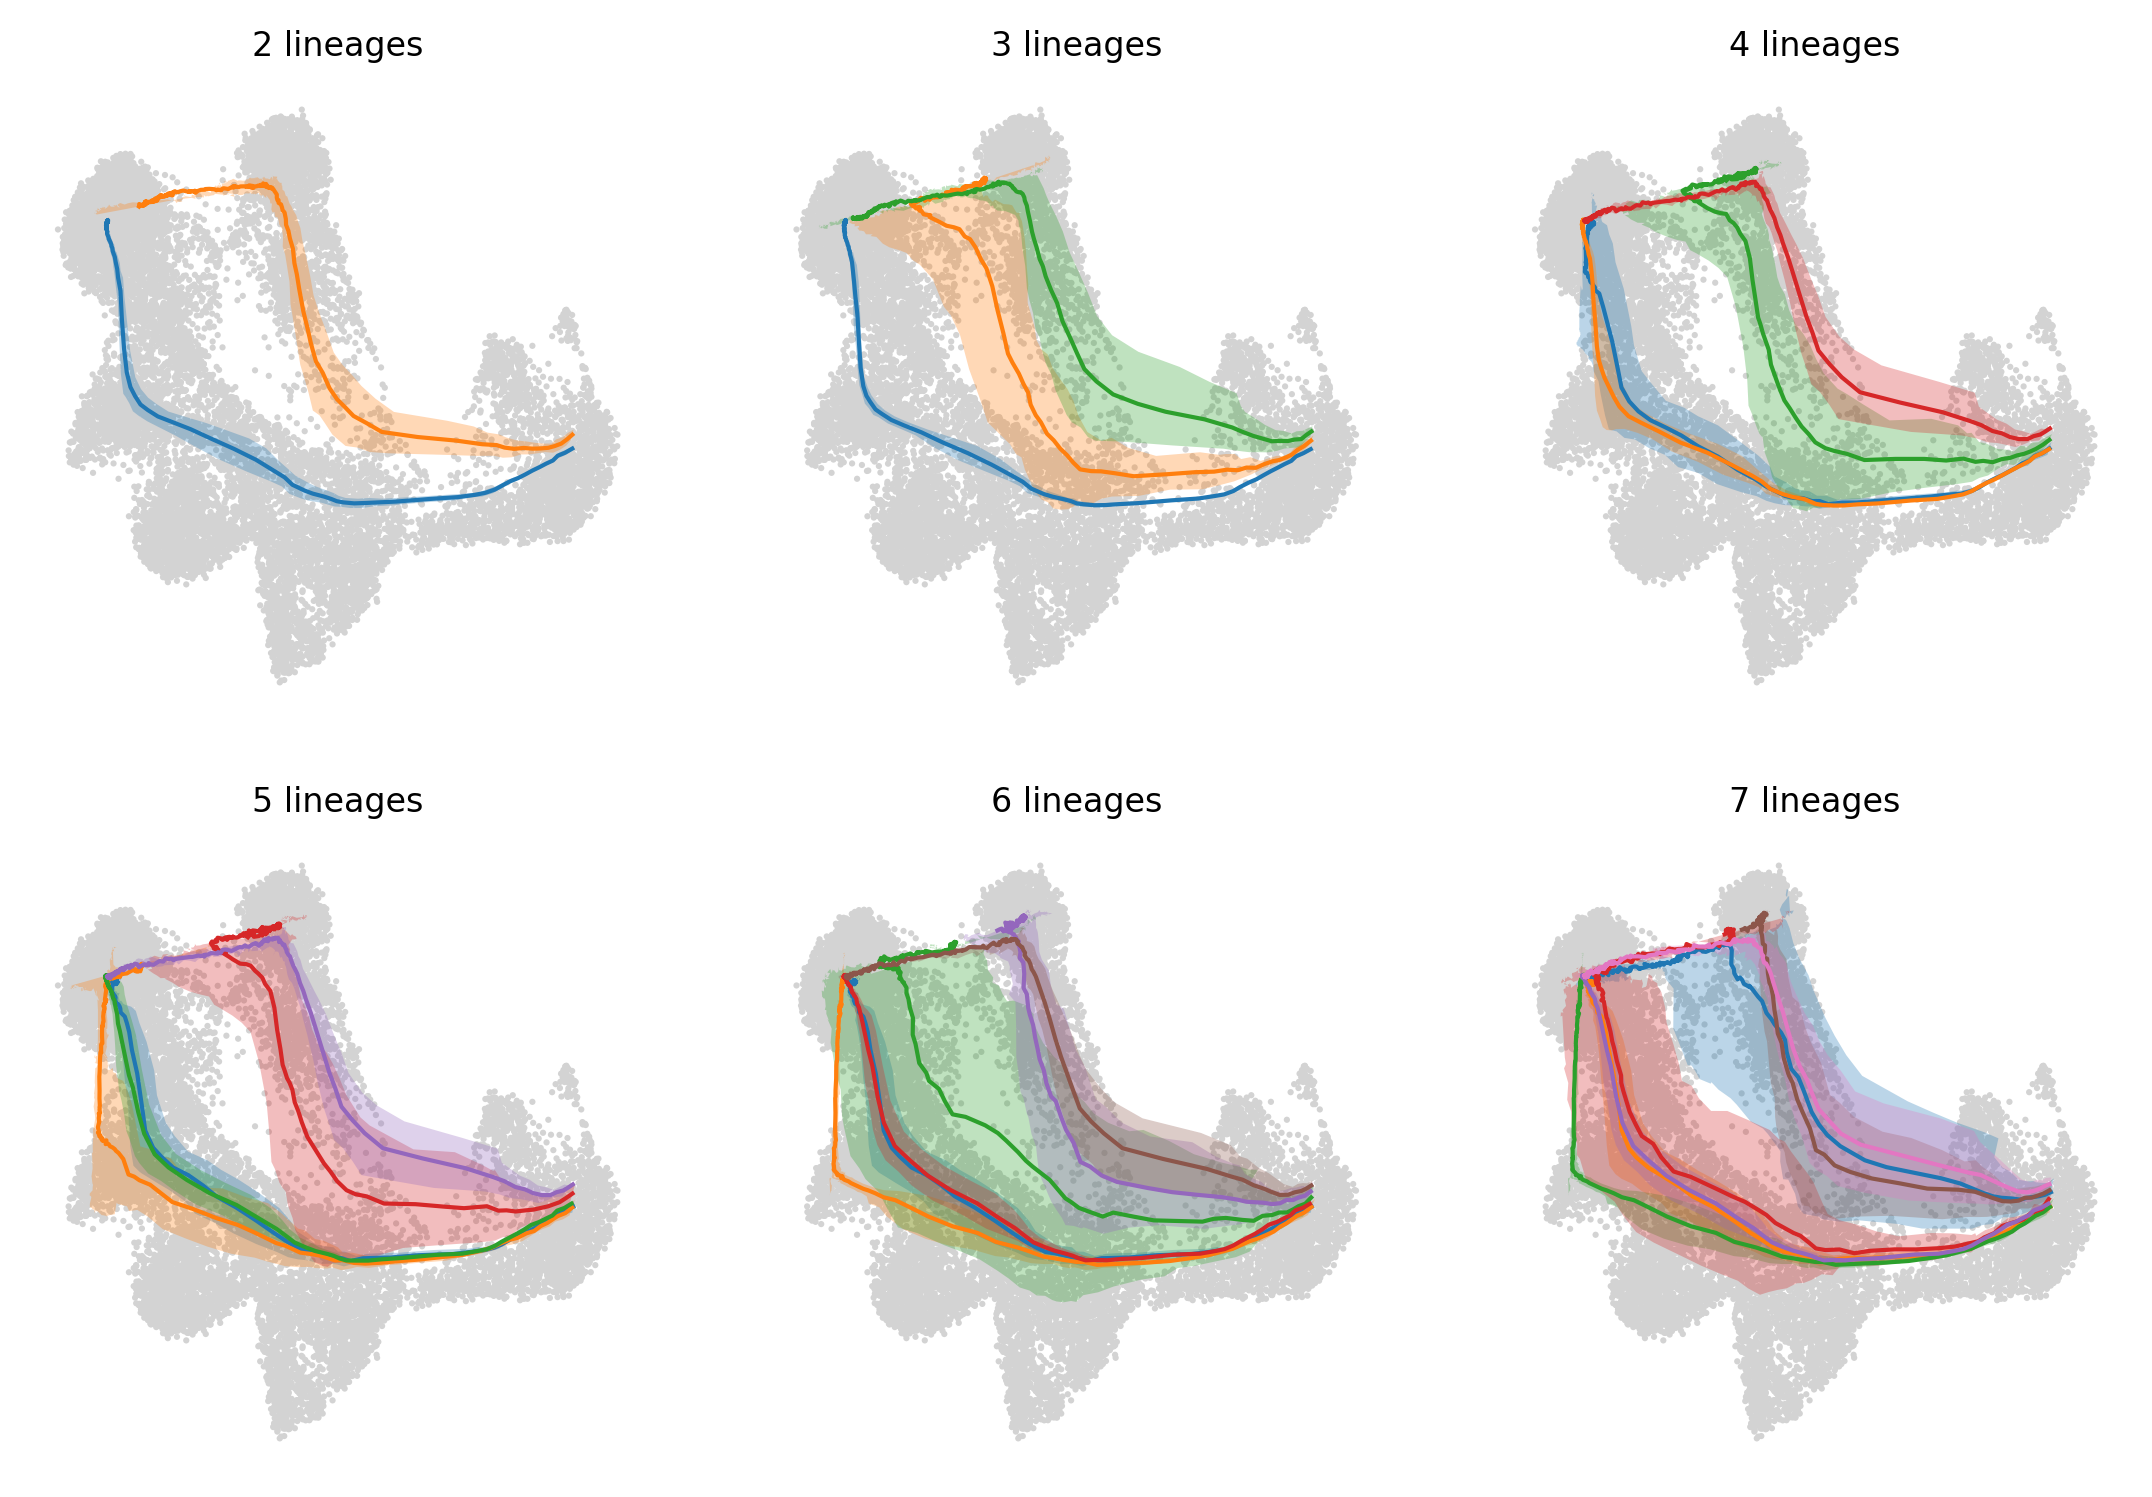

In [ ]:
# Plot trajectories and their uncertainty
fig, axs = plt.subplots(2, 3, figsize=(9, 6))

for i, n_lineages in enumerate(range(2, 8)):
    ax = axs.flat[i]
    sc.pl.umap(adata, ax=ax, show=False, frameon=False)
    for j, lineage in enumerate(lineage_coords_mean[n_lineages]):
        color = f"C{i}"
        ax.plot(lineage[:, 0], lineage[:, 1], lw=1, c=color)
        region_lower = lineage - lineage_coords_std[n_lineages][j]
        region_upper = lineage + lineage_coords_std[n_lineages][j]
        xf = np.concatenate((region_lower[:, 0], region_upper[:, 0][::-1]))
        yf = np.concatenate((region_lower[:, 1], region_upper[:, 1][::-1]))
        ax.fill(xf, yf, c=color, alpha=0.3, lw=0)
    ax.set_title(f"{n_lineages} lineages", fontsize=8)

In [ ]:
for n_lineages, coords in lineage_coords_all.items():
    np.save(f"{LINEAGE_PATH}/lineage_coords_all_{n_lineages}_lineages.npy", coords)
    np.save(
        f"{LINEAGE_PATH}/lineage_coords_mean_{n_lineages}_lineages.npy",
        lineage_coords_mean[n_lineages],
    )
    np.save(
        f"{LINEAGE_PATH}/lineage_coords_std_{n_lineages}_lineages.npy",
        lineage_coords_std[n_lineages],
    )